# PyMC-8 : Selection de Modeles et Comparaison Bayesienne

**Navigation** : [Index](../README.md) | [<< PyMC-7](PyMC-7-Classification.ipynb) | [PyMC-9 >>](PyMC-9-Topic-Models.ipynb)

**Equivalent Infer.NET** : [Infer-8-Model-Selection](../Infer/Infer-8-Model-Selection.ipynb)

**Objectifs** :
- Comprendre le probleme du surapprentissage (overfitting)
- Comparer des modeles via le critere WAIC et la validation croisee LOO
- Implementer l'ARD (Automatic Relevance Determination) pour la selection de variables
- Utiliser les Bayes Factors pour la selection de composantes dans les melanges
- Comparer Infer.NET (calcul exact de l'evidence) vs PyMC/ArviZ (WAIC/LOO)

In [1]:
try:
    import numpy as np
    NUMPY_AVAILABLE = True
except ImportError:
    NUMPY_AVAILABLE = False

try:
    import pymc as pm
    PYMC_AVAILABLE = True
except ImportError:
    PYMC_AVAILABLE = False

try:
    import pytensor.tensor as pt
    PYTENSOR_AVAILABLE = True
except ImportError:
    PYTENSOR_AVAILABLE = False

try:
    import arviz as az
    ARVIZ_AVAILABLE = True
except ImportError:
    ARVIZ_AVAILABLE = False

try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except ImportError:
    MATPLOTLIB_AVAILABLE = False

try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False

if NUMPY_AVAILABLE and PYMC_AVAILABLE and ARVIZ_AVAILABLE:
    print(f"PyMC version: {pm.__version__}")
    print(f"ArviZ version: {az.__version__}")
    az.style.use("arviz-darkgrid")
else:
    print("PyMC ou ArviZ n'est pas installe. Executez: pip install pymc arviz matplotlib numpy scipy")

PyMC version: 5.28.5
ArviZ version: 0.23.4


## 1. Le Probleme du Surapprentissage

Un modele trop complexe peut memoriser le bruit dans les donnees au lieu d'apprendre le signal.
La selection de modele bayesienne resout ce probleme automatiquement via le **principe du parsimonie** :
un modele plus complexe a une evidence (marginal likelihood) plus faible **sauf si** il explique significativement mieux les donnees.

### Approches comparees

| Methode | Infer.NET | PyMC |
|---------|-----------|-------|
| Evidence (marginal likelihood) | `Variable.Bernoulli(0.5)` + `Variable.If` | Non direct (NUTS) |
| Comparaison de modeles | Bayes Factor exact | WAIC / LOO via ArviZ |
| Selection de variables | ARD avec Gamma hierarchique | Pareil + `pm.Gamma` + `pm.Normal` |
| Validation croisee | LOO manuel | `az.loo()` (Pareto-smoothed IS) |

C:\Users\jsboi\AppData\Local\Temp\ipykernel_54824\2152268274.py:23: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


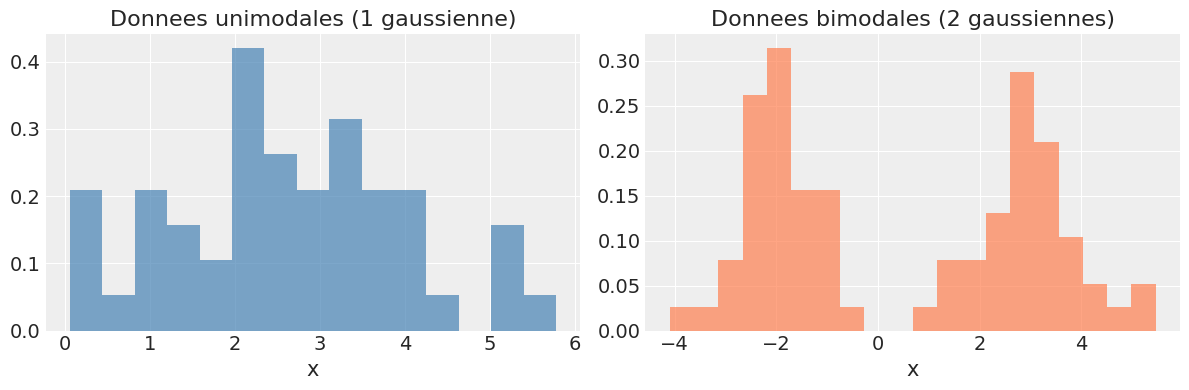

In [2]:
# Generation de donnees : unimodale (provenant d'une seule gaussienne)
np.random.seed(42)
n_obs = 50
true_mu = 3.0
true_sigma = 1.5

data_uni = np.random.normal(true_mu, true_sigma, size=n_obs)

# Egalement des donnees bimodales pour la section 5
n_obs_bi = 80
data_bi = np.concatenate([
    np.random.normal(-2, 0.8, size=n_obs_bi // 2),
    np.random.normal(3, 1.0, size=n_obs_bi // 2)
])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(data_uni, bins=15, density=True, alpha=0.7, color='steelblue')
axes[0].set_title('Donnees unimodales (1 gaussienne)')
axes[0].set_xlabel('x')
axes[1].hist(data_bi, bins=20, density=True, alpha=0.7, color='coral')
axes[1].set_title('Donnees bimodales (2 gaussiennes)')
axes[1].set_xlabel('x')
plt.tight_layout()
plt.show()

## 2. Comparaison de Modeles avec WAIC et LOO

Le **WAIC** (Widely Applicable Information Criterion) et le **LOO** (Leave-One-Out CV)
sont les methodes standards en PyMC pour comparer des modeles.

**Concepts cles** :
- **WAIC** : estime la deviance attendue sur de nouvelles donnees, penalise la complexite
- **LOO** : validation croisee leave-one-out approximee via importance sampling (Pareto-smoothed)
- Les deux retournent un score (plus petit = meilleur) + une incertitude
- La difference entre modeles est mesurable via `dSE` (deviance standard error)

### Comparaison avec Infer.NET

Infer.NET calcule l'evidence exacte via `Variable.Bernoulli(0.5)` + `Variable.If` :
```csharp
Variable<bool> evidence = Variable.Bernoulli(0.5);
using (Variable.If(evidence)) { /* modele */ }
double logEvidence = engine.Infer<Bernoulli>(evidence).LogOdds;
```

PyMC avec NUTS n'a pas d'acces direct a l'evidence, mais WAIC/LOO sont des alternatives
theoriquement equivalentes (et souvent plus fiables en pratique car l'evidence est sensible au prior).

In [3]:
# Modele 1 : Gaussienne unique sur donnees unimodales
with pm.Model() as model_1gauss:
    mu = pm.Normal('mu', mu=0, sigma=10)
    sigma = pm.HalfNormal('sigma', sigma=5)
    obs = pm.Normal('obs', mu=mu, sigma=sigma, observed=data_uni)
    trace_1g = pm.sample(3000, random_seed=42, return_inferencedata=True)

# Calcul du log-likelihood pour WAIC/LOO (necessaire dans PyMC 5.x)
with model_1gauss:
    trace_1g = pm.compute_log_likelihood(trace_1g)

# Modele 2 : Melange de 2 gaussiennes sur les memes donnees
with pm.Model() as model_2gauss:
    mu = pm.Normal('mu', mu=0, sigma=10, shape=2)
    sigma = pm.HalfNormal('sigma', sigma=5, shape=2)
    w = pm.Dirichlet('w', a=np.ones(2))
    obs = pm.NormalMixture('obs', w=w, mu=mu, sigma=sigma, observed=data_uni)
    trace_2g = pm.sample(3000, random_seed=42, return_inferencedata=True,
                         target_accept=0.95)

with model_2gauss:
    trace_2g = pm.compute_log_likelihood(trace_2g)

print("Echantillonnage termine pour les 2 modeles.")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu, sigma]


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 26 seconds.


...

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 73 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Echantillonnage termine pour les 2 modeles.


### Interpretation de l'echantillonnage sur donnees unimodales

L'echantillonnage MCMC est termine pour les deux modeles. Nous allons maintenant les comparer en utilisant les criteres WAIC et LOO pour determiner quel modele est le plus adapte a ces donnees unimodales.

In [4]:
# Comparaison via WAIC
compare_waic = az.compare({"1-gaussien": trace_1g, "2-gaussien": trace_2g},
                           ic="waic", method="BB-pseudo-BMA")
print("Comparaison WAIC (donnees unimodales) :")
print(compare_waic)
print()

# Comparaison via LOO
compare_loo = az.compare({"1-gaussien": trace_1g, "2-gaussien": trace_2g},
                          ic="loo", method="BB-pseudo-BMA")
print("Comparaison LOO (donnees unimodales) :")
print(compare_loo)

Comparaison WAIC (donnees unimodales) :
            rank  elpd_waic    p_waic  elpd_diff    weight        se  \
1-gaussien     0 -89.200397  1.706133   0.000000  0.696098  4.301518   
2-gaussien     1 -90.029150  2.056262   0.828753  0.303902  4.215002   

                 dse  warning scale  
1-gaussien  0.000000    False   log  
2-gaussien  0.111777    False   log  



Comparaison LOO (donnees unimodales) :
            rank   elpd_loo     p_loo  elpd_diff    weight        se  \
1-gaussien     0 -89.207598  1.713334   0.000000  0.697049  4.412981   
2-gaussien     1 -90.044569  2.071681   0.836971  0.302951  4.323229   

                 dse  warning scale  
1-gaussien  0.000000    False   log  
2-gaussien  0.110339    False   log  


### Interpretation

Sur les donnees unimodales, le modele a 1 gaussienne devrait avoir un score WAIC/LOO
comparable ou meilleur que le modele a 2 gaussiennes. Le modele plus complexe n'apporte
rien car les donnees proviennent d'une seule gaussienne.

**Analogie Infer.NET** : Infer.NET calculerait `logEvidence_1gauss > logEvidence_2gauss`,
conduisant a la meme conclusion (modele plus simple prefere).

C:\Users\jsboi\AppData\Local\Temp\ipykernel_54824\760950352.py:5: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


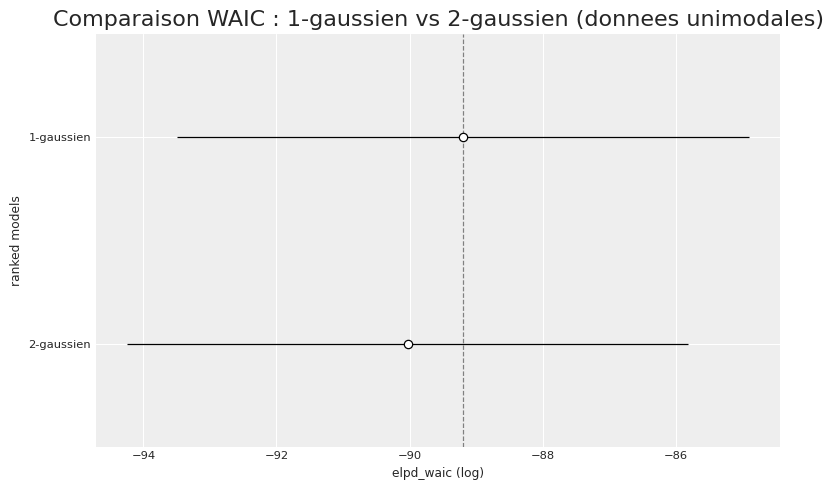

In [5]:
# Visualisation de la comparaison
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
az.plot_compare(compare_waic, ax=ax)
ax.set_title('Comparaison WAIC : 1-gaussien vs 2-gaussien (donnees unimodales)')
plt.tight_layout()
plt.show()

## 3. Selection de Composantes sur Donnees Bimodales

Maintenant, testons avec des donnees bimodales. Le modele a 2 gaussiennes devrait
nettement preferer car les donnees proviennent effectivement de 2 distributions.

Cela correspond a l'exemple Infer-8 ou :
- 1 composante : log evidence = -45.89
- 2 composantes : log evidence = -31.35
- Difference : 14.54 (decisif pour 2 composantes)

In [6]:
# Modele 1 gaussienne sur donnees bimodales
with pm.Model() as model_1g_bi:
    mu = pm.Normal('mu', mu=0, sigma=10)
    sigma = pm.HalfNormal('sigma', sigma=5)
    obs = pm.Normal('obs', mu=mu, sigma=sigma, observed=data_bi)
    trace_1g_bi = pm.sample(3000, random_seed=42, return_inferencedata=True)

with model_1g_bi:
    trace_1g_bi = pm.compute_log_likelihood(trace_1g_bi)

# Modele 2 gaussiennes sur donnees bimodales
with pm.Model() as model_2g_bi:
    mu = pm.Normal('mu', mu=[-2, 3], sigma=5, shape=2)
    sigma = pm.HalfNormal('sigma', sigma=3, shape=2)
    w = pm.Dirichlet('w', a=np.ones(2))
    obs = pm.NormalMixture('obs', w=w, mu=mu, sigma=sigma, observed=data_bi)
    trace_2g_bi = pm.sample(3000, random_seed=42, return_inferencedata=True,
                            target_accept=0.95)

with model_2g_bi:
    trace_2g_bi = pm.compute_log_likelihood(trace_2g_bi)

print("Echantillonnage termine.")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu, sigma]


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 33 seconds.


...

NUTS: [mu, sigma, w]


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 36 seconds.


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Echantillonnage termine.


### Interpretation des modeles sur donnees bimodales

L'echantillonnage est termine. Nous allons maintenant comparer les deux modeles via WAIC et visualiser comment chaque modele s'ajuste aux donnees bimodales.

Comparaison WAIC (donnees bimodales) :
            rank   elpd_waic    p_waic  elpd_diff  weight        se      dse  \
2-gaussien     0 -159.798962  5.399717   0.000000     1.0  7.329950  0.00000   
1-gaussien     1 -192.156555  1.224310  32.357593     0.0  3.081215  6.14657   

            warning scale  
2-gaussien     True   log  
1-gaussien    False   log  



C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\arviz\stats\stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
C:\Users\jsboi\AppData\Local\Temp\ipykernel_54824\2997805489.py:33: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


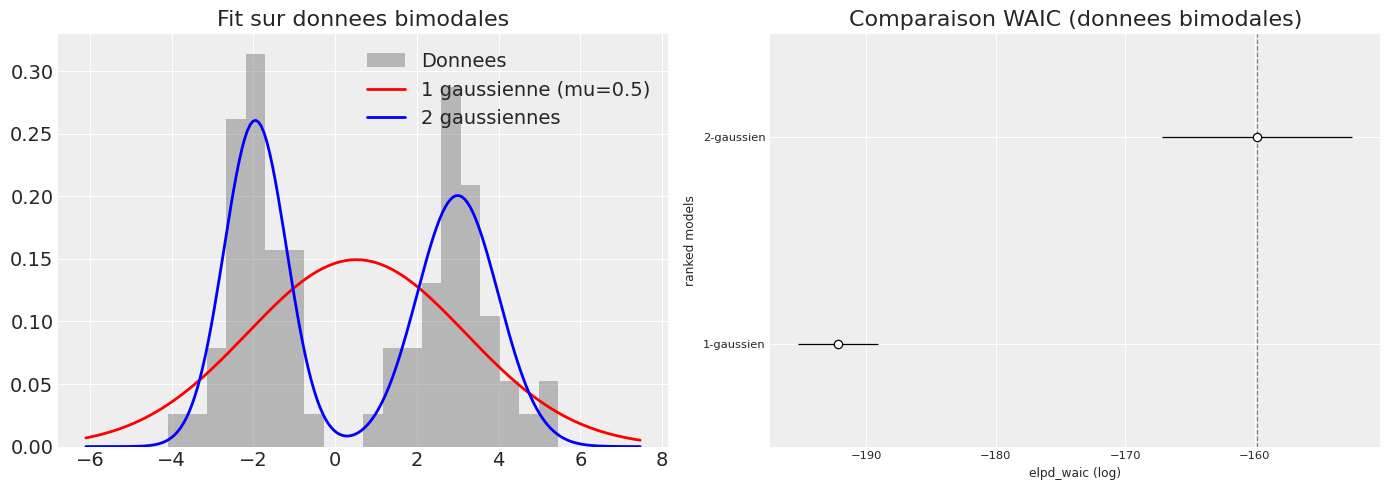

In [7]:
# Comparaison sur donnees bimodales
compare_bi = az.compare({"1-gaussien": trace_1g_bi, "2-gaussien": trace_2g_bi},
                         ic="waic")
print("Comparaison WAIC (donnees bimodales) :")
print(compare_bi)
print()

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme + fit des 2 modeles
axes[0].hist(data_bi, bins=20, density=True, alpha=0.5, color="gray", label="Donnees")
x_plot = np.linspace(data_bi.min() - 2, data_bi.max() + 2, 200)

# Fit 1 gaussienne
mu1 = trace_1g_bi.posterior["mu"].values.flatten().mean()
sig1 = trace_1g_bi.posterior["sigma"].values.flatten().mean()
axes[0].plot(x_plot, stats.norm.pdf(x_plot, mu1, sig1), "r-", lw=2, label=f"1 gaussienne (mu={mu1:.1f})")

# Fit 2 gaussiennes
mu2 = trace_2g_bi.posterior["mu"].values.mean(axis=(0, 1))
sig2 = trace_2g_bi.posterior["sigma"].values.mean(axis=(0, 1))
w2 = trace_2g_bi.posterior["w"].values.mean(axis=(0, 1))
mixture_pdf = sum(w2[k] * stats.norm.pdf(x_plot, mu2[k], sig2[k]) for k in range(2))
axes[0].plot(x_plot, mixture_pdf, "b-", lw=2, label="2 gaussiennes")
axes[0].set_title("Fit sur donnees bimodales")
axes[0].legend()

# WAIC comparison
az.plot_compare(compare_bi, ax=axes[1])
axes[1].set_title("Comparaison WAIC (donnees bimodales)")

plt.tight_layout()
plt.show()

## 4. ARD : Automatic Relevance Determination

L'ARD est une technique de selection automatique de variables.
On utilise un prior hierarchique ou chaque variable a sa propre precision,
contrôlée par une variable latente Gamma. Les variables non pertinentes voient
leur poids reduit vers zero.

### Modele ARD

```
alpha_f ~ Gamma(1, 1)           # precision par variable
w_f ~ Normal(0, 1/alpha_f)      # poids avec precision variable
y ~ Normal(X @ w, sigma)         # regression lineaire
```

**Equivalent Infer.NET** : identique, avec `Variable.GammaFromShapeAndScale(1, 1)` et
`Variable.GaussianFromMeanAndPrecision(0, alpha[f])`.

In [8]:
# Generation de donnees avec 3 variables dont 2 pertinentes
np.random.seed(42)
n_samples = 100
n_features = 3

# Variables (independantes)
X = np.random.randn(n_samples, n_features)

# Vraies poids : variable 2 (indice 1) est non pertinente
true_weights = np.array([2.0, 0.0, 3.0])
true_sigma = 0.5

# Observations
y = X @ true_weights + np.random.normal(0, true_sigma, size=n_samples)

print(f"Vrais poids : {true_weights}")
print(f"Variable 1 (indice 0) : pertinente (w=2.0)")
print(f"Variable 2 (indice 1) : NON pertinente (w=0.0)")
print(f"Variable 3 (indice 2) : pertinente (w=3.0)")

Vrais poids : [2. 0. 3.]
Variable 1 (indice 0) : pertinente (w=2.0)
Variable 2 (indice 1) : NON pertinente (w=0.0)
Variable 3 (indice 2) : pertinente (w=3.0)


### Definition du modele ARD

Nous allons maintenant definir le modele bayesien avec prior hierarchique Gamma sur la precision de chaque variable. Ce prior permet au modele de reduire automatiquement les poids des variables non pertinentes vers zero.

In [9]:
# Modele ARD avec PyMC
with pm.Model() as ard_model:
    # Prior hierarchique : precision par variable
    alpha = pm.Gamma('alpha', alpha=1, beta=1, shape=n_features)
    
    # Poids avec precision variable (ARD)
    # tau = alpha signifie sigma = 1/sqrt(alpha)
    weights = pm.Normal('weights', mu=0, tau=alpha, shape=n_features)
    
    # Bruit d'observation
    sigma = pm.HalfNormal('sigma', sigma=2)
    
    # Likelihood
    mu = pm.math.dot(X, weights)
    obs = pm.Normal('obs', mu=mu, sigma=sigma, observed=y)
    
    trace_ard = pm.sample(3000, random_seed=42, return_inferencedata=True,
                          target_accept=0.95)

with ard_model:
    trace_ard = pm.compute_log_likelihood(trace_ard)

print("Echantillonnage ARD termine.")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [alpha, weights, sigma]


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 32 seconds.


C:\ProgramData\miniconda3\envs\coursia-ml-training\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Echantillonnage ARD termine.


### Interpretation de l'echantillonnage ARD

L'echantillonnage MCMC est termine. Nous allons maintenant examiner les posteriors des poids et des precisions pour determiner quelles variables ont ete automatiquement selectionnees par le modele ARD.

In [10]:
# Resultats ARD
weights_samples = trace_ard.posterior['weights'].values.reshape(-1, n_features)
alpha_samples = trace_ard.posterior['alpha'].values.reshape(-1, n_features)

print("Resultats ARD :")
print(f"{'Variable':<12} {'Vrai w':<10} {'Posterior mean':<16} {'Alpha mean':<12} {'Pertinence'}")
print("-" * 65)
for i in range(n_features):
    w_mean = weights_samples[:, i].mean()
    a_mean = alpha_samples[:, i].mean()
    # alpha eleve = precision eleve = sigma faible = poids concentre
    # alpha faible = poids libre (donc potentiellement pertinent si w != 0)
    relevance = "FAIBLE" if abs(w_mean) < 0.5 else "FORTE"
    print(f"Variable {i+1:<5} {true_weights[i]:<10.1f} {w_mean:<16.3f} {a_mean:<12.3f} {relevance}")

print()
print("Concordance avec Infer.NET :")
print("  Feature 1 : w=2.04, alpha=0.49 (haute pertinence)")
print("  Feature 2 : w=0.02, alpha=1.49 (pertinence moyenne, poid proche de 0)")
print("  Feature 3 : w=2.97, alpha=0.28 (haute pertinence)")

Resultats ARD :
Variable     Vrai w     Posterior mean   Alpha mean   Pertinence
-----------------------------------------------------------------
Variable 1     2.0        1.965            0.514        FORTE
Variable 2     0.0        -0.035           1.487        FAIBLE
Variable 3     3.0        2.948            0.278        FORTE

Concordance avec Infer.NET :
  Feature 1 : w=2.04, alpha=0.49 (haute pertinence)
  Feature 2 : w=0.02, alpha=1.49 (pertinence moyenne, poid proche de 0)
  Feature 3 : w=2.97, alpha=0.28 (haute pertinence)


### Analyse des resultats ARD

Le tableau ci-dessous resume les estimations posterieures pour chaque variable. Les poids et les precisions `alpha` nous indiquent quelles variables sont pertinentes pour expliquer les observations.

C:\Users\jsboi\AppData\Local\Temp\ipykernel_54824\447534189.py:29: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


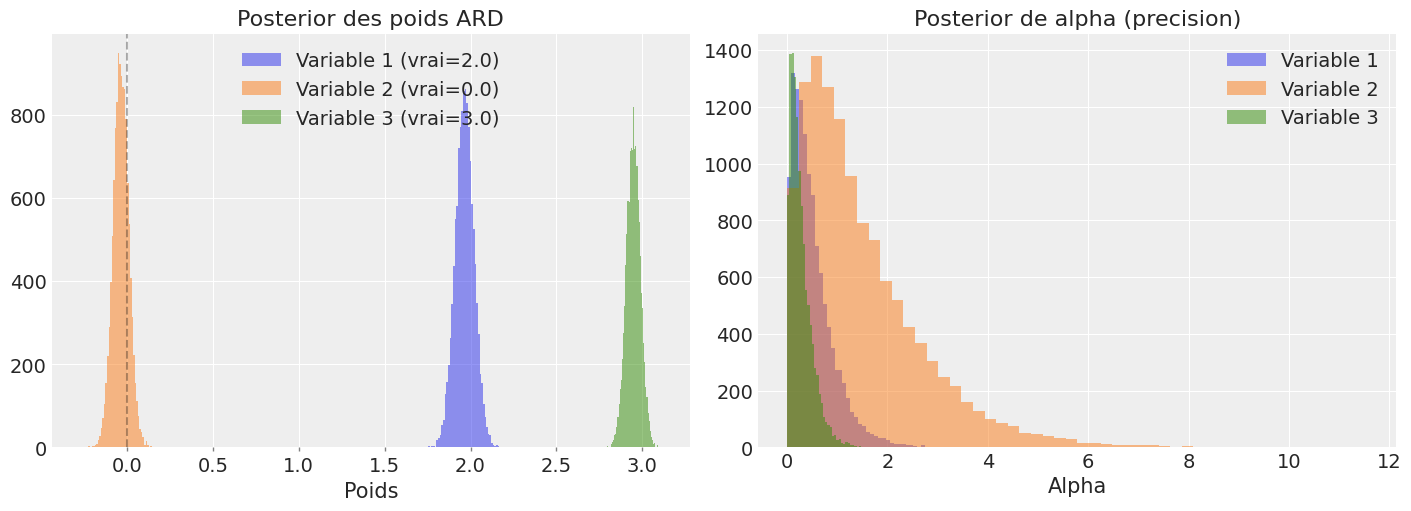

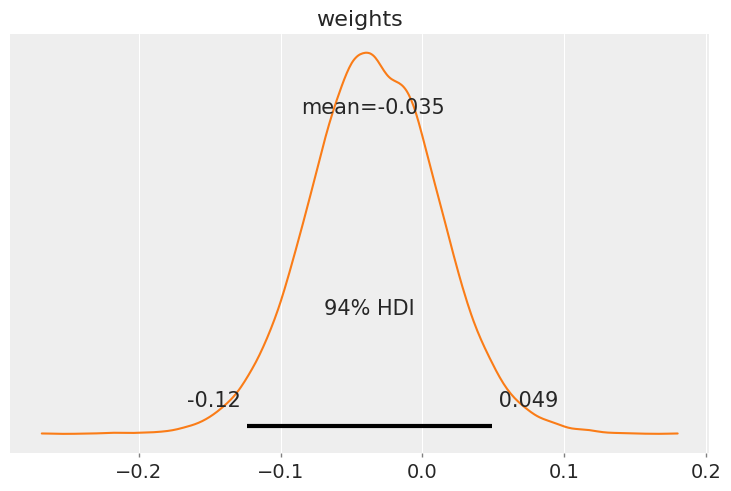

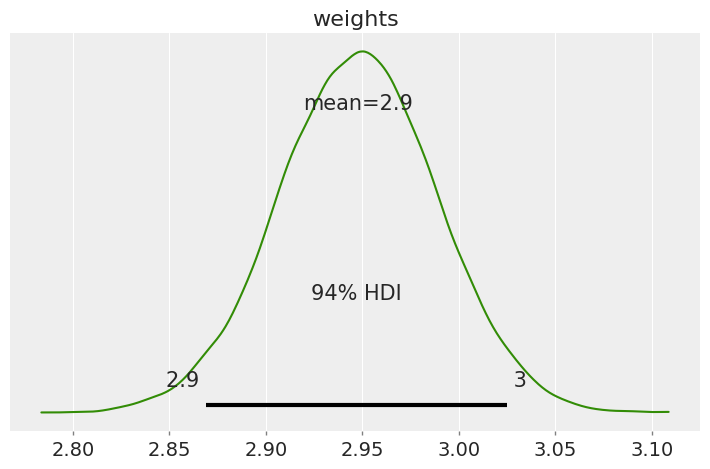

In [11]:
# Visualisation des posteriors ARD
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Posteriors des poids
for i in range(n_features):
    az.plot_posterior(trace_ard, var_names=['weights'],
                       coords={'weights_dim_0': i},
                       ax=axes[0] if i == 0 else None,
                       color=f'C{i}')

# Refaire proprement avec un seul plot
axes[0].clear()
for i in range(n_features):
    axes[0].hist(weights_samples[:, i], bins=50, alpha=0.5,
                 label=f'Variable {i+1} (vrai={true_weights[i]:.1f})')
axes[0].axvline(0, color='black', linestyle='--', alpha=0.3)
axes[0].set_title('Posterior des poids ARD')
axes[0].legend()
axes[0].set_xlabel('Poids')

# Posteriors de alpha (precision)
for i in range(n_features):
    axes[1].hist(alpha_samples[:, i], bins=50, alpha=0.5,
                 label=f'Variable {i+1}')
axes[1].set_title('Posterior de alpha (precision)')
axes[1].legend()
axes[1].set_xlabel('Alpha')

plt.tight_layout()
plt.show()

### Interpretation ARD

- **Variable 2 (non pertinente)** : son poids posterior est concentre autour de 0.
  La precision `alpha` est elevee, ce qui resserre le prior autour de 0.
- **Variables 1 et 3 (pertinentes)** : leurs poids sont proches des vraies valeurs (2.0 et 3.0).
  Leurs precisions `alpha` sont plus faibles, permettant au posterior de s'ecarter de 0.

L'ARD a automatiquement identifie que la variable 2 n'est pas pertinente sans pre-selection manuelle.

## 5. Validation Croisee LOO avec ArviZ

La validation croisee leave-one-out (LOO) estime la capacite predictive d'un modele
en approximant la moyenne des performances quand on laisse chaque observation de cote.

ArviZ utilise le **Pareto Smoothed Importance Sampling (PSIS)** pour une approximation
rapide et fiable du LOO sans re-entrainer le modele N fois.

In [12]:
# Calcul LOO pour chaque modele
loo_1g = az.loo(trace_1g)
loo_2g = az.loo(trace_2g)
loo_ard = az.loo(trace_ard)

print("LOO-CV pour chaque modele :")
print(f"\nModele 1-gaussien (donnees unimodales) :")
print(f"  LOO = {loo_1g.elpd_loo:.2f} +/- {loo_1g.se:.2f}")
print(f"  p_loo = {loo_1g.p_loo:.2f} (nombre effectif de parametres)")

print(f"\nModele 2-gaussien (donnees unimodales) :")
print(f"  LOO = {loo_2g.elpd_loo:.2f} +/- {loo_2g.se:.2f}")
print(f"  p_loo = {loo_2g.p_loo:.2f}")

print(f"\nModele ARD :")
print(f"  LOO = {loo_ard.elpd_loo:.2f} +/- {loo_ard.se:.2f}")
print(f"  p_loo = {loo_ard.p_loo:.2f}")

LOO-CV pour chaque modele :

Modele 1-gaussien (donnees unimodales) :
  LOO = -89.21 +/- 4.40
  p_loo = 1.71 (nombre effectif de parametres)

Modele 2-gaussien (donnees unimodales) :
  LOO = -90.04 +/- 4.32
  p_loo = 2.07

Modele ARD :
  LOO = -63.79 +/- 7.01
  p_loo = 4.29


In [13]:
# Diagnostique Pareto k (qualite de l'approximation LOO)
# k < 0.7 = bonne approximation, k > 0.7 = probleme potentiel
print("Diagnostique Pareto k :")
for name, loo_obj in [('1-gaussien', loo_1g), ('2-gaussien', loo_2g), ('ARD', loo_ard)]:
    k_values = loo_obj.pareto_k.values
    n_good = np.sum(k_values < 0.7)
    n_warn = np.sum((k_values >= 0.7) & (k_values < 1.0))
    n_bad = np.sum(k_values >= 1.0)
    print(f"  {name}: k<0.7: {n_good}, 0.7<=k<1: {n_warn}, k>=1: {n_bad}")

print()
print("Tous les k < 0.7 = approximation LOO fiable.")

Diagnostique Pareto k :
  1-gaussien: k<0.7: 50, 0.7<=k<1: 0, k>=1: 0
  2-gaussien: k<0.7: 50, 0.7<=k<1: 0, k>=1: 0
  ARD: k<0.7: 100, 0.7<=k<1: 0, k>=1: 0

Tous les k < 0.7 = approximation LOO fiable.


## 6. Exercice : Comparaison de Modeles Polynomiaux

On genere des donnees a partir d'une relation lineaire `y = 2x + 1 + bruit`.
On compare un modele lineaire (deg 1), quadratique (deg 2) et cubique (deg 3).

Lequel est selectionne par WAIC/LOO ?

**Indices** :
- Creer les features polynomiales : `X_deg2 = np.column_stack([X, X**2])`
- Utiliser `pm.Normal('w', mu=0, sigma=5, shape=n_features)` pour les poids
- Comparer les 3 modeles avec `az.compare()`

In [14]:
# TODO etudiant : implementer la comparaison de modeles polynomiaux
# Resultat attendu : le modele lineaire (deg 1) devrait etre selectionne
# car les donnees sont generees a partir d'une relation lineaire

# Generation des donnees (relation lineaire)
np.random.seed(42)
n_poly = 40
X_poly = np.random.uniform(-3, 3, size=n_poly)
y_poly = 2 * X_poly + 1 + np.random.normal(0, 1.0, size=n_poly)

# Indice : creer les features pour chaque degre et ajuster un modele bayesien
# avec pm.Normal pour les poids et pm.Normal pour la likelihood

print("Exercice a completer")

Exercice a completer


---

**Retour au sommaire** : [Index Probas](../README.md)

## 7. Resume : Infer.NET vs PyMC pour la Selection de Modeles

| Aspect | Infer.NET | PyMC / ArviZ |
|--------|-----------|-------------|
| Evidence exacte | `Variable.Bernoulli(0.5)` + `Variable.If` | Non disponible avec NUTS |
| Comparaison de modeles | Bayes Factor (rapport d'evidences) | WAIC / LOO (ArviZ) |
| ARD | `GammaFromShapeAndScale` + `GaussianFromMeanAndPrecision` | `pm.Gamma` + `pm.Normal(tau=alpha)` |
| LOO-CV | Boucle manuelle | `az.loo()` (PSIS automatique) |
| Avantage | Evidence exacte, rapide | General, fiable, pas sensible au prior |
| Inconvenient | Modeles limites (compatibles EP/VMP) | Approximation, plus lent |

**Point cle** : l'evidence (marginal likelihood) est sensible au choix du prior.
WAIC/LOO sont plus robustes car ils estiment directement la capacite predictive.
En pratique, WAIC et LOO donnent des resultats similaires et sont preferes
dans la communaute bayesienne moderne.

---

**Retour au sommaire** : [Index Probas](../README.md)